# 🌸 Multi-Model Image Classification with PyTorch
## Flower Classification using Transfer Learning

This notebook compares multiple pretrained models for flower classification:
- **ResNet50** - Deep Residual Network
- **VGG16** - Visual Geometry Group Network
- **EfficientNet-B0** - Efficient Neural Network
- **MobileNetV3** - Mobile-optimized Network
- **ConvNeXt-Tiny** - Modern ConvNet (2022)
- **DenseNet121** - Densely Connected Network

## 1. Import Libraries & Setup

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## 2. Configuration

In [4]:
# Hyperparameters
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 5  # Epochs per model
LEARNING_RATE = 0.001
NUM_WORKERS = 0  # Set to 0 for Windows compatibility

# Models to compare
MODEL_LIST = [
    'resnet50',
    'vgg16',
    'efficientnet_b0',
    'mobilenet_v3',
    'convnext_tiny',
    'densenet121'
]

print(f"Configuration:")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Epochs per model: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Models to compare: {MODEL_LIST}")

Configuration:
  Batch Size: 32
  Image Size: 224x224
  Epochs per model: 5
  Learning Rate: 0.001
  Models to compare: ['resnet50', 'vgg16', 'efficientnet_b0', 'mobilenet_v3', 'convnext_tiny', 'densenet121']


## 3. Data Preparation

In [5]:
# Data Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Data transforms defined!")

Data transforms defined!


In [6]:
# Load Datasets
train_dataset = datasets.ImageFolder("dataset/train", transform=train_transform)
val_dataset = datasets.ImageFolder("dataset/valid", transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Classes: {class_names[:10]}... (showing first 10)")

Number of classes: 102
Training samples: 6552
Validation samples: 818
Classes: ['1', '10', '100', '101', '102', '11', '12', '13', '14', '15']... (showing first 10)


In [7]:
# Flower names mapping (Oxford Flowers 102)
flower_names = [
    'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold',
    'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle',
    'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris',
    'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'giant white arum lily',
    'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth',
    'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william',
    'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly',
    'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'lenten rose',
    'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower',
    'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy',
    'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium',
    'orange dahlia', 'pink-yellow dahlia', 'cautleya spicata', 'japanese anemone', 'black-eyed susan',
    'silverbush', 'californian poppy', 'osteospermum', 'spring crocus', 'bearded iris',
    'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily', 'rose',
    'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily',
    'anthurium', 'frangipani', 'clematis', 'hibiscus', 'columbine',
    'desert-rose', 'tree mallow', 'magnolia', 'cyclamen', 'watercress',
    'canna lily', 'hippeastrum', 'bee balm', 'ball moss', 'foxglove',
    'bougainvillea', 'camellia', 'mallow', 'mexican petunia', 'bromelia',
    'blanket flower', 'trumpet creeper', 'blackberry lily'
]

idx_to_flower = {i: flower_names[i] for i in range(len(flower_names))}
print(f"✅ Loaded {len(flower_names)} flower names")
print(f"\nSample mappings:")
for i in range(5):
    print(f"  Class {i}: {flower_names[i]}")

✅ Loaded 102 flower names

Sample mappings:
  Class 0: pink primrose
  Class 1: hard-leaved pocket orchid
  Class 2: canterbury bells
  Class 3: sweet pea
  Class 4: english marigold


## 4. Visualize Sample Images

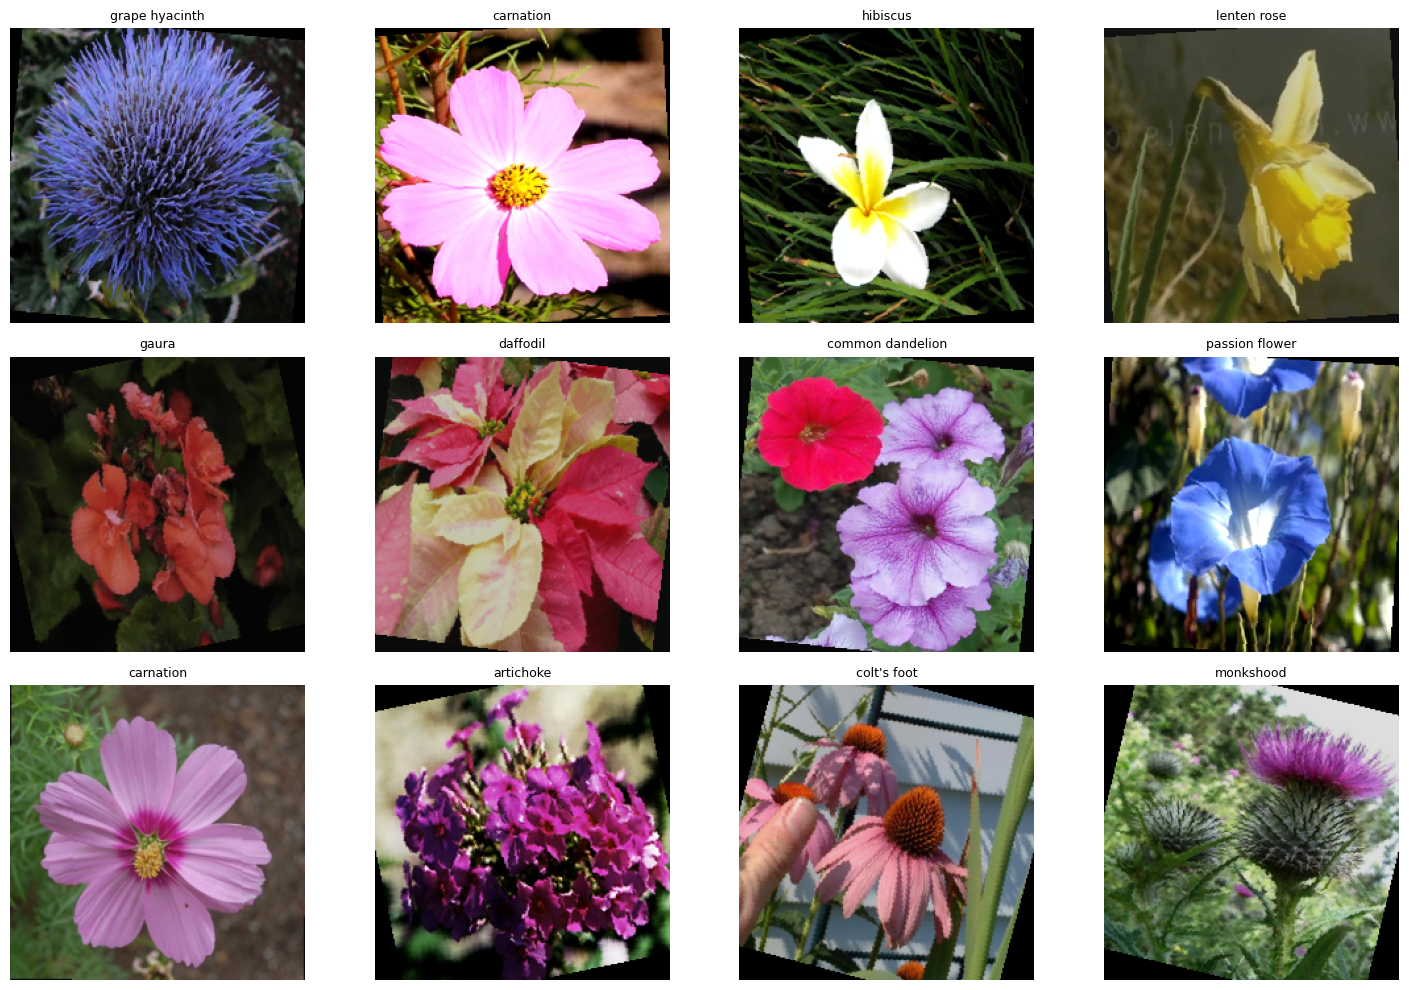

In [8]:
# Visualize some training images
def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)

# Get a batch of training data
images, labels = next(iter(train_loader))

plt.figure(figsize=(15, 10))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    imshow(images[i])
    label_idx = labels[i].item()
    if label_idx < len(flower_names):
        plt.title(flower_names[label_idx], fontsize=9)
    else:
        plt.title(f"Class {label_idx}", fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Model Creation Function

In [9]:
def create_model(model_name, num_classes, pretrained=True):
    """
    Create a pretrained model with a custom classification head.
    
    Args:
        model_name: Name of the model architecture
        num_classes: Number of output classes
        pretrained: Whether to use pretrained weights
    
    Returns:
        model: PyTorch model ready for training
    """
    weights = 'IMAGENET1K_V1' if pretrained else None
    
    if model_name == 'resnet50':
        model = models.resnet50(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    elif model_name == 'vgg16':
        model = models.vgg16(weights=weights)
        for param in model.features.parameters():
            param.requires_grad = False
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    elif model_name == 'mobilenet_v3':
        model = models.mobilenet_v3_large(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        num_ftrs = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        num_ftrs = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'densenet121':
        model = models.densenet121(weights=weights)
        for param in model.parameters():
            param.requires_grad = False
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    return model.to(device)

print("Model creation function defined!")

Model creation function defined!


## 6. Training Function

In [10]:
def train_model(model, model_name, train_loader, val_loader, epochs=5):
    """
    Train a model and return training history.
    """
    print(f"\n{'='*60}")
    print(f"🚀 Training: {model_name.upper()}")
    print(f"{'='*60}")
    
    criterion = nn.CrossEntropyLoss()
    
    # Get trainable parameters
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=LEARNING_RATE)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'epoch_time': []
    }
    
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        epoch_start = time.time()
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]', ncols=100)
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{train_correct/train_total:.4f}'})
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]  ', ncols=100)
        with torch.no_grad():
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                val_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{val_correct/val_total:.4f}'})
        
        scheduler.step()
        
        # Calculate epoch metrics
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = val_correct / val_total
        epoch_time = time.time() - epoch_start
        
        # Save history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['epoch_time'].append(epoch_time)
        
        # Update best accuracy
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
        
        print(f"\n📊 Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f} | "
              f"Time: {epoch_time:.1f}s\n")
    
    history['best_val_acc'] = best_val_acc
    return history, model

print("Training function defined!")

Training function defined!


## 7. Train All Models

In [11]:
# Store all results
all_results = {}
trained_models = {}

print("\n" + "="*60)
print("🔬 MULTI-MODEL COMPARISON EXPERIMENT")
print("="*60)
print(f"Models to compare: {MODEL_LIST}")
print(f"Epochs per model: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print("="*60)

for model_name in MODEL_LIST:
    try:
        # Create model
        print(f"\n📦 Loading {model_name}...")
        model = create_model(model_name, num_classes)
        
        # Train model
        history, trained_model = train_model(model, model_name, train_loader, val_loader, epochs=EPOCHS)
        
        # Store results
        all_results[model_name] = history
        trained_models[model_name] = trained_model
        
        # Clean up to free GPU memory
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        
    except Exception as e:
        print(f"❌ Error training {model_name}: {e}")
        continue

print("\n✅ All models trained!")


🔬 MULTI-MODEL COMPARISON EXPERIMENT
Models to compare: ['resnet50', 'vgg16', 'efficientnet_b0', 'mobilenet_v3', 'convnext_tiny', 'densenet121']
Epochs per model: 5
Batch size: 32
Learning rate: 0.001

📦 Loading resnet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 27.4MB/s]



🚀 Training: RESNET50


Epoch 1/5 [Val]  : 100%|███████████████████| 26/26 [00:55<00:00,  2.12s/it, loss=2.3379, acc=0.5232]



📊 Epoch [1/5] | Train Loss: 3.6359, Train Acc: 0.2063 | Val Loss: 2.1795, Val Acc: 0.5232 | Time: 603.4s



...


📊 Epoch [5/5] | Train Loss: 0.3230, Train Acc: 0.9612 | Val Loss: 0.3463, Val Acc: 0.9450 | Time: 466.1s


📦 Loading densenet121...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\User/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:01<00:00, 28.2MB/s]



🚀 Training: DENSENET121


Epoch 1/5 [Train]:  10%|█▊                | 21/205 [01:07<09:52,  3.22s/it, loss=4.4397, acc=0.0417]


KeyboardInterrupt: 

## 8. Results Summary

In [12]:
print("\n" + "="*60)
print("📊 FINAL RESULTS SUMMARY")
print("="*60)

# Create comparison table
print(f"\n{'Model':<20} {'Best Val Acc':<15} {'Final Val Acc':<15} {'Total Time':<15}")
print("-" * 65)

best_model = None
best_acc = 0

for model_name, history in all_results.items():
    best_val_acc = history['best_val_acc']
    final_val_acc = history['val_acc'][-1]
    total_time = sum(history['epoch_time'])
    
    print(f"{model_name:<20} {best_val_acc*100:.2f}%{'':<8} {final_val_acc*100:.2f}%{'':<8} {total_time:.1f}s")
    
    if best_val_acc > best_acc:
        best_acc = best_val_acc
        best_model = model_name

print("-" * 65)
print(f"\n🏆 BEST MODEL: {best_model.upper()} with {best_acc*100:.2f}% validation accuracy!")


📊 FINAL RESULTS SUMMARY

Model                Best Val Acc    Final Val Acc   Total Time     
-----------------------------------------------------------------
resnet50             79.71%         79.71%         2941.1s
vgg16                63.08%         63.08%         6310.1s
efficientnet_b0      85.21%         84.47%         1378.4s
mobilenet_v3         94.62%         94.62%         896.3s
convnext_tiny        94.50%         94.50%         2279.6s
-----------------------------------------------------------------

🏆 BEST MODEL: MOBILENET_V3 with 94.62% validation accuracy!


## 9. Visualization

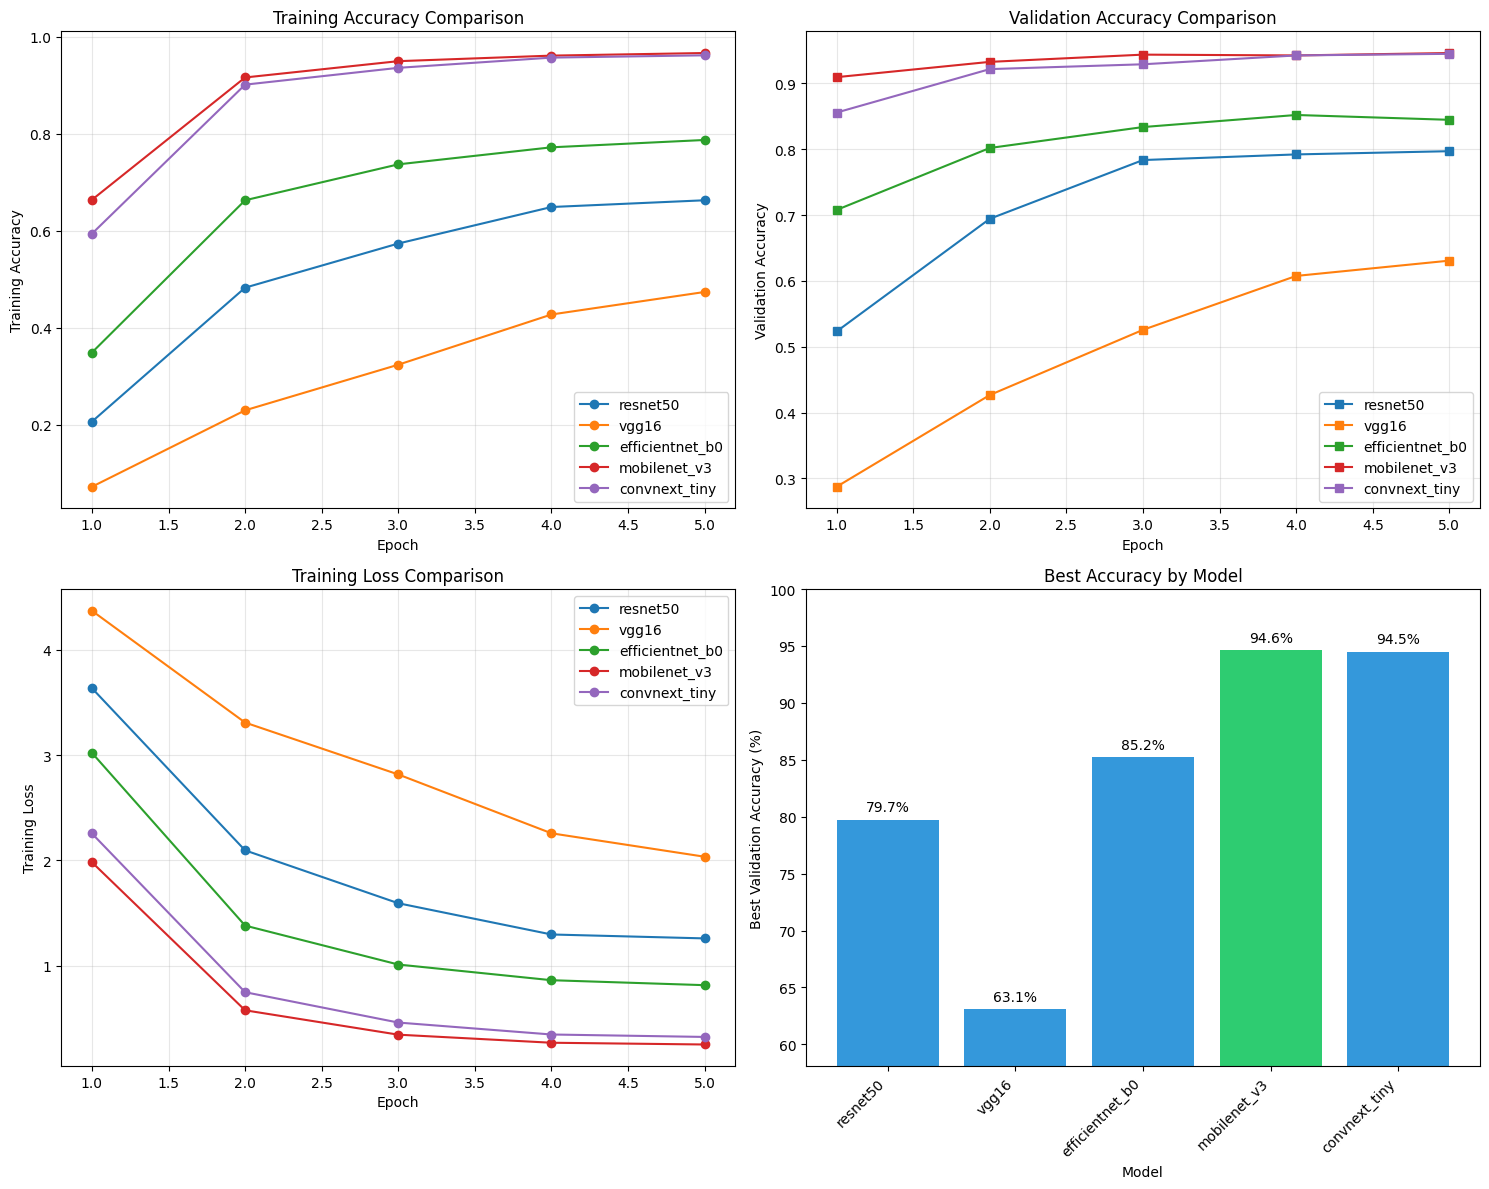


✅ Results saved to 'model_comparison_results.png'


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Training Accuracy
ax1 = axes[0, 0]
for model_name, history in all_results.items():
    ax1.plot(range(1, EPOCHS+1), history['train_acc'], marker='o', label=model_name)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Accuracy')
ax1.set_title('Training Accuracy Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Validation Accuracy
ax2 = axes[0, 1]
for model_name, history in all_results.items():
    ax2.plot(range(1, EPOCHS+1), history['val_acc'], marker='s', label=model_name)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validation Accuracy Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Training Loss
ax3 = axes[1, 0]
for model_name, history in all_results.items():
    ax3.plot(range(1, EPOCHS+1), history['train_loss'], marker='o', label=model_name)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Training Loss')
ax3.set_title('Training Loss Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Best Accuracy Bar Chart
ax4 = axes[1, 1]
models = list(all_results.keys())
accuracies = [all_results[m]['best_val_acc'] * 100 for m in models]
colors = ['#2ecc71' if m == best_model else '#3498db' for m in models]
bars = ax4.bar(models, accuracies, color=colors)
ax4.set_xlabel('Model')
ax4.set_ylabel('Best Validation Accuracy (%)')
ax4.set_title('Best Accuracy by Model')
ax4.set_ylim([min(accuracies)-5, 100])
plt.xticks(rotation=45, ha='right')
for bar, acc in zip(bars, accuracies):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Results saved to 'model_comparison_results.png'")

## 10. Test Best Model on Sample Images


🔍 Testing best model: MOBILENET_V3


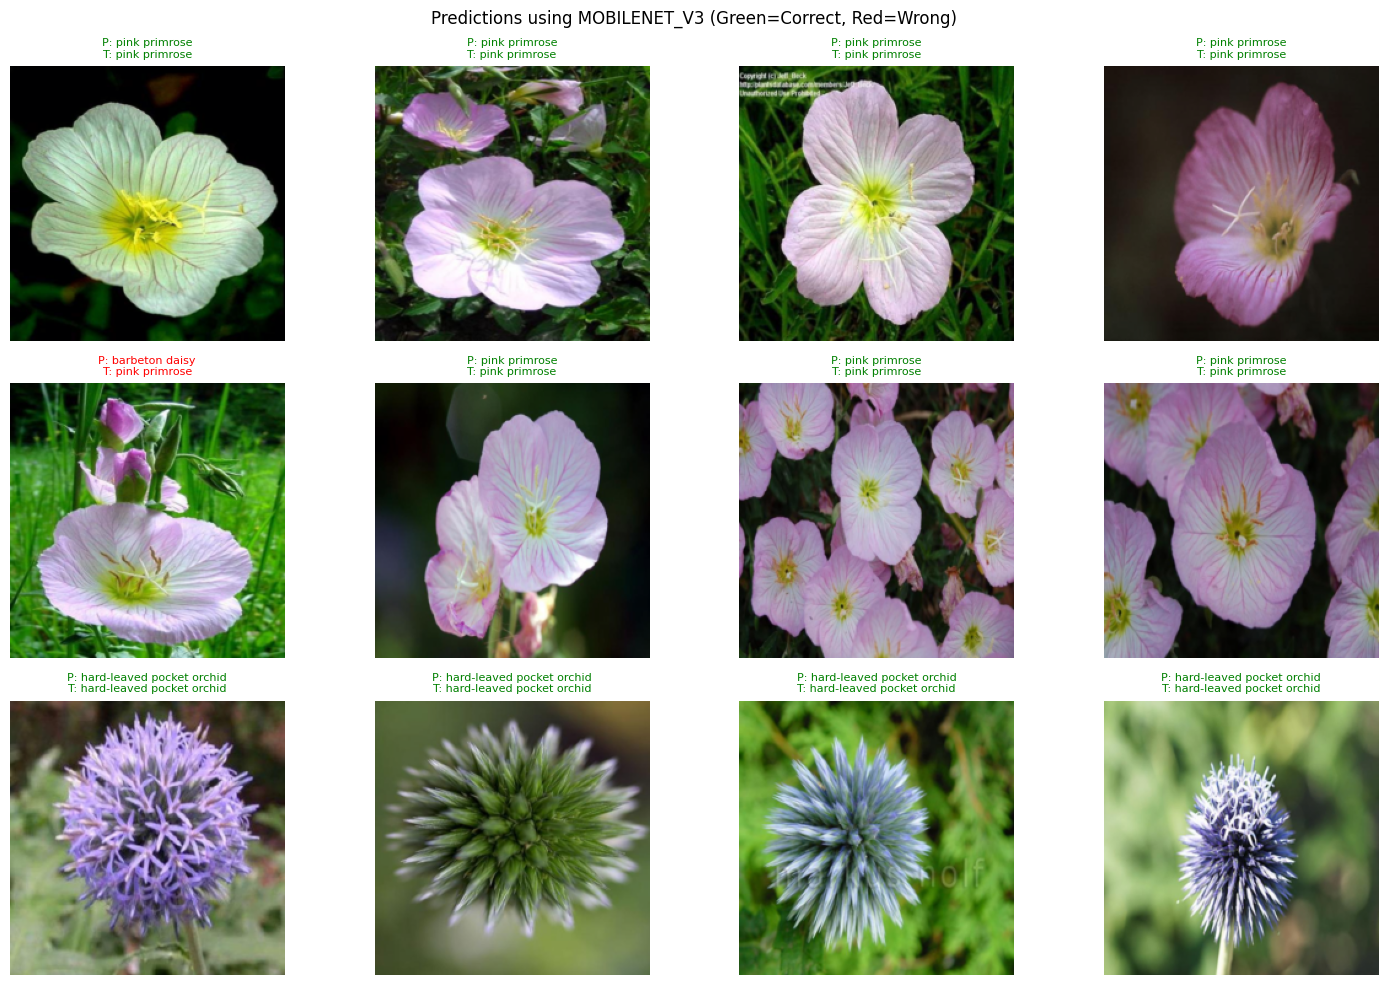

In [14]:
# Test the best model on validation images
print(f"\n🔍 Testing best model: {best_model.upper()}")

best_trained_model = trained_models[best_model]
best_trained_model.eval()

# Get sample images
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = best_trained_model(images)
    _, predicted = torch.max(outputs, 1)

# Visualize predictions
plt.figure(figsize=(15, 10))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    
    # Denormalize image
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    
    pred_idx = predicted[i].item()
    true_idx = labels[i].item()
    
    # Get flower names
    pred_name = flower_names[pred_idx] if pred_idx < len(flower_names) else f'Class {pred_idx}'
    true_name = flower_names[true_idx] if true_idx < len(flower_names) else f'Class {true_idx}'
    
    color = 'green' if pred_idx == true_idx else 'red'
    plt.title(f'P: {pred_name}\nT: {true_name}', fontsize=8, color=color)
    plt.axis('off')

plt.suptitle(f'Predictions using {best_model.upper()} (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Save Best Model

In [15]:
# Save the best model
best_model_path = f'best_model_{best_model}.pth'
torch.save({
    'model_name': best_model,
    'model_state_dict': trained_models[best_model].state_dict(),
    'num_classes': num_classes,
    'best_val_acc': best_acc,
    'class_names': class_names,
    'flower_names': flower_names
}, best_model_path)

print(f"\n✅ Best model saved to '{best_model_path}'")
print(f"   Model: {best_model.upper()}")
print(f"   Best Validation Accuracy: {best_acc*100:.2f}%")


✅ Best model saved to 'best_model_mobilenet_v3.pth'
   Model: MOBILENET_V3
   Best Validation Accuracy: 94.62%


## 12. Final Summary

In [16]:
print("\n" + "="*60)
print("📋 EXPERIMENT COMPLETE")
print("="*60)
print(f"\n✅ Trained {len(all_results)} models:")
for i, model_name in enumerate(all_results.keys(), 1):
    acc = all_results[model_name]['best_val_acc'] * 100
    print(f"   {i}. {model_name}: {acc:.2f}%")

print(f"\n🏆 Best Model: {best_model.upper()} ({best_acc*100:.2f}%)")
print(f"\n📁 Saved files:")
print(f"   - model_comparison_results.png")
print(f"   - best_model_{best_model}.pth")
print("\n" + "="*60)


📋 EXPERIMENT COMPLETE

✅ Trained 5 models:
   1. resnet50: 79.71%
   2. vgg16: 63.08%
   3. efficientnet_b0: 85.21%
   4. mobilenet_v3: 94.62%
   5. convnext_tiny: 94.50%

🏆 Best Model: MOBILENET_V3 (94.62%)

📁 Saved files:
   - model_comparison_results.png
   - best_model_mobilenet_v3.pth

